# Music Genre Classification - Version 1

This notebook implements a clean, production-like baseline for the Music Genre Classification task.
It uses a Random Forest model with 5-fold Stratified Cross-Validation, similar to the successful `v1_baseline.ipynb`.

## Goals:
1. Load and inspect data.
2. Preprocess numeric features (Median Imputation + Standard Scaling).
3. Train Random Forest with Stratified K-Fold.
4. Evaluate using F1 Macro and Confusion Matrix.
5. Generate submission file.

## Imports & Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

# Add src to path
sys.path.append(os.path.abspath("src"))

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import mode

# Import custom modules
from evaluation.Evaluation import Evaluation
from tracking.Tracking import Tracking

# Configuration
RANDOM_STATE = 42
N_SPLITS = 5
DATA_DIR = "data"
EXP_DIR = "experiments/Music_V1"

os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(os.path.join(EXP_DIR, "models"), exist_ok=True)

np.random.seed(RANDOM_STATE)

## 1. Load Data

In [2]:
train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

display(train_df.head())

# Check Class distribution
target_col = "Class"
print("\nClass Distribution:")
print(train_df[target_col].value_counts(normalize=True))

Train shape: (14396, 18)
Test shape: (3600, 17)


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5



Class Distribution:
Class
10    0.275007
6     0.143720
9     0.140247
8     0.103015
5     0.080370
1     0.076271
2     0.070714
0     0.034732
7     0.032023
3     0.022367
4     0.021534
Name: proportion, dtype: float64


## 2. Feature Definition & Preprocessing

We use the same numeric features as the baseline.

In [3]:
NUM_FEATURES = [
    "Popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_in min/ms",
    "time_signature",
]

X = train_df[NUM_FEATURES].copy()
y = train_df[target_col].copy()
X_test = test_df[NUM_FEATURES].copy()

# Define Preprocessing Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
    ]
)

# Define Model
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model),
    ]
)

## 3. Cross-Validation Training (5 Folds)

In [4]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(y), dtype=int)
fold_metrics = []
models = []

print(f"Starting {N_SPLITS}-Fold CV...")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\n========== Fold {fold} ==========")
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
    
    # Clone pipeline
    from sklearn.base import clone
    model = clone(clf)
    
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    val_preds = model.predict(X_val)
    oof_preds[valid_idx] = val_preds
    
    # Evaluate
    f1 = f1_score(y_val, val_preds, average="macro")
    acc = accuracy_score(y_val, val_preds)
    print(f"Fold {fold} F1 Macro: {f1:.4f} | Accuracy: {acc:.4f}")
    
    fold_metrics.append(f1)
    models.append(model)
    
    # Save model
    model_path = os.path.join(EXP_DIR, "models", f"fold{fold}_rf.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

# OOF Score
oof_f1 = f1_score(y, oof_preds, average="macro")
print("\n========== OOF Results ==========")
print(f"Mean F1 Macro: {np.mean(fold_metrics):.4f} ± {np.std(fold_metrics):.4f}")
print(f"OOF F1 Macro: {oof_f1:.4f}")

Starting 5-Fold CV...

========== Fold 0 ==========
Fold 0 F1 Macro: 0.5604 | Accuracy: 0.5056

========== Fold 1 ==========
Fold 1 F1 Macro: 0.5600 | Accuracy: 0.5165

========== Fold 2 ==========
Fold 2 F1 Macro: 0.5596 | Accuracy: 0.5196

========== Fold 3 ==========
Fold 3 F1 Macro: 0.5596 | Accuracy: 0.5189

========== Fold 4 ==========
Fold 4 F1 Macro: 0.5634 | Accuracy: 0.5050

========== OOF Results ==========
Mean F1 Macro: 0.5606 ± 0.0014
OOF F1 Macro: 0.5608


## 4. Evaluation & Diagnostics
Using the custom `Evaluation` class to visualize results.


Detailed Evaluation on Last Fold:

🔹 Evaluation Report for RandomForest_Fold4 (classification)
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       100
           1       0.04      0.02      0.02       220
           2       0.62      0.35      0.45       204
           3       0.80      0.86      0.83        64
           4       0.67      0.65      0.66        62
           5       0.70      0.69      0.70       231
           6       0.31      0.24      0.27       414
           7       0.97      0.95      0.96        92
           8       0.60      0.48      0.53       297
           9       0.53      0.52      0.52       403
          10       0.44      0.64      0.52       792

    accuracy                           0.51      2879
   macro avg       0.58      0.56      0.56      2879
weighted avg       0.49      0.51      0.49      2879


 Tổng hợp metrics:
                   RandomForest_Fold4
Accuracy                     0.50

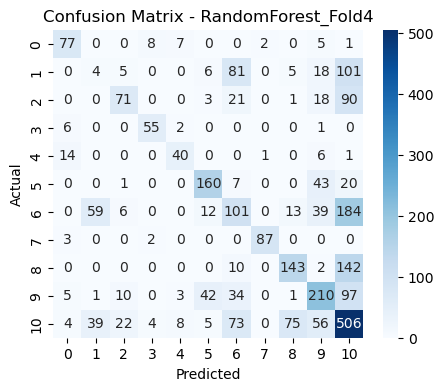

⚠️ Mô hình không có thông tin feature importance.


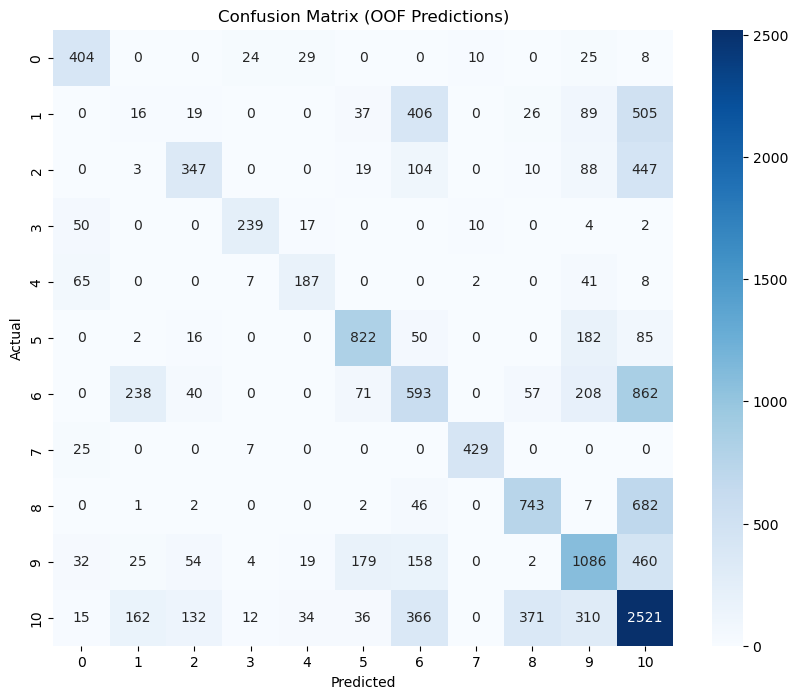

In [5]:
# We can use the Evaluation class on the OOF predictions or the last fold
# Here we use a dummy wrapper to use Evaluation class with OOF predictions if we had probabilities
# Or we can just use it on the last fold for demonstration

print("\nDetailed Evaluation on Last Fold:")
evaluator = Evaluation(models[-1], X_val, y_val, model_name="RandomForest_Fold4", task="classification")
metrics = evaluator.full_evaluation()

# Confusion Matrix for OOF
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (OOF Predictions)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. Final Prediction & Submission
We use majority voting from the 5 fold models.

In [6]:
test_preds_all = []

for i, model in enumerate(models):
    preds = model.predict(X_test)
    test_preds_all.append(preds)

test_preds_all = np.stack(test_preds_all, axis=0)

# Majority Vote
test_final_preds, _ = mode(test_preds_all, axis=0, keepdims=False)
test_final_preds = test_final_preds.flatten()

# --- LABEL DECODING ---
# Note: The competition requires string labels. 
# If you have a mapping (e.g. {0: 'Pop', 1: 'Rock'}), apply it here.
# Since the training data has integer labels, we assume integers are expected or we lack the mapping.
# Uncomment and update the below line if you have the mapping:
# label_mapping = {0: 'Genre A', 1: 'Genre B', ...}
# test_final_labels = [label_mapping[p] for p in test_final_preds]

# For now, we submit the integer predictions as in the baseline.
submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
submission["Class"] = test_final_preds

sub_path = os.path.join(EXP_DIR, "submission_version1.csv")
submission.to_csv(sub_path, index=False)

print(f"Saved submission to: {sub_path}")
display(submission.head())

Saved submission to: experiments/Music_V1\submission_version1.csv


,Id,Class
0,14397,6
1,14398,6
2,14399,9
3,14400,10
4,14401,5


## 6. Save Artifacts

In [7]:
# Save OOF predictions
with open(os.path.join(EXP_DIR, "oof_preds.pkl"), "wb") as f:
    pickle.dump(oof_preds, f)

# Save Metrics
metrics_dict = {
    "fold_f1_macro": fold_metrics,
    "mean_f1_macro": float(np.mean(fold_metrics)),
    "std_f1_macro": float(np.std(fold_metrics)),
    "oof_f1_macro": float(oof_f1)
}

with open(os.path.join(EXP_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_dict, f, indent=2)

print("Artifacts saved.")

Artifacts saved.
